In [1]:
!pip install timm

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
from timm.models.layers import trunc_normal_, DropPath, to_2tuple
from timm.models.registry import register_model
from tqdm.notebook import tqdm
import os
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import h5py
from torch.utils.data import DataLoader,Dataset,random_split
from torchvision import transforms as T

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [2]:
class JetDataset(Dataset):
    def __init__(self, path, augment=False):
        self.file = h5py.File(path, "r")
        self.images = self.file["jet"]
        self.labels = self.file["Y"]
        self.augment = augment
        self.aug_transforms = T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.RandomRotation(degrees=15)  # small rotation is safer
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        image = image.permute(2, 0, 1)
        if self.augment:
            image = self.aug_transforms(image)
        image = (image - image.mean()) / (image.std() + 1e-6)
        return image, label

In [3]:
path = "/content/drive/MyDrive/CERN/Dataset_Specific_labelled.h5"

In [4]:
total_size = len(JetDataset(path))
train_size = int(0.7 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

base_dataset = JetDataset(path, augment=False)

train_idx, val_idx, test_idx = random_split(
    range(total_size),
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [5]:

from torch.utils.data import Subset
train_dataset = Subset(JetDataset(path, augment=True), train_idx.indices)
val_dataset   = Subset(JetDataset(path, augment=False), val_idx.indices)
test_dataset  = Subset(JetDataset(path, augment=False), test_idx.indices)

In [6]:
batch_size = 128
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [7]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([128, 8, 125, 125])
torch.Size([128, 1])


In [8]:
class LayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_last"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        self.normalized_shape = (normalized_shape,)

    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            x = self.weight[:, None, None] * x + self.bias[:, None, None]
            return x

def build_norm(cfg, dim):
    cfg_ = cfg.copy()
    layer_type = cfg_.pop('type')
    if layer_type == 'SyncBN':
        return nn.SyncBatchNorm(dim)
    elif layer_type == 'LN':
        return nn.LayerNorm(dim)
    elif layer_type == 'LN_custom':
        return LayerNorm(dim, eps=1e-6, data_format="channels_first")
    else:
        return nn.BatchNorm2d(dim)


In [9]:
class Mul(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, q, k):
        return q @ k

class CustomSequential(nn.Sequential):
    def forward(self, *inputs):
        for module in self._modules.values():
            if type(inputs) == tuple:
                inputs = module(*inputs)
            else:
                inputs = module(inputs)
        return inputs

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None,
                 act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

class CPE(nn.Module):
    def __init__(self, dim, k=3, act=False):
        super(CPE, self).__init__()
        self.proj = nn.Conv2d(dim, dim, to_2tuple(k), to_2tuple(1), to_2tuple(k // 2), groups=dim)
        self.activation = nn.GELU() if act else nn.Identity()

    def forward(self, x, size):
        B, N, C = x.shape
        H, W = size
        assert N == H * W
        feat = x.transpose(1, 2).contiguous().view(B, C, H, W)
        feat = self.proj(feat)
        feat = feat.flatten(2).transpose(1, 2)
        x = x + self.activation(feat)
        return x


In [10]:
def window_partition(x, window_size: int):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size: int, H: int, W: int):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, attn_drop=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
        self.softmax = nn.Softmax(dim=-1)
        self.attn_drop = nn.Dropout(attn_drop)
        self.qk_mul = Mul()
        self.kv_mul = Mul()

    def forward(self, x):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = q * self.scale
        attn = self.qk_mul(q, k.transpose(-2, -1))
        attn = self.softmax(attn)
        attn = self.attn_drop(attn)
        x = self.kv_mul(attn, v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        return x

class LWABlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=7, mlp_ratio=4., qkv_bias=True, drop_path=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm, ffn=True, cpe_act=False, **kwargs):
        super().__init__()
        self.dim = dim
        self.ffn = ffn
        self.num_heads = num_heads
        self.window_size = window_size
        self.mlp_ratio = mlp_ratio

        self.cpe = nn.ModuleList([CPE(dim=dim, k=3, act=cpe_act), CPE(dim=dim, k=3, act=cpe_act)])
        self.norm1 = norm_layer(dim)
        self.attn = WindowAttention(dim, window_size=to_2tuple(self.window_size), num_heads=num_heads, qkv_bias=qkv_bias)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()

        if self.ffn:
            self.norm2 = norm_layer(dim)
            mlp_hidden_dim = int(dim * mlp_ratio)
            self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer)

    def forward(self, x, size):
        H, W = size
        B, L, C = x.shape
        assert L == H * W

        shortcut = self.cpe[0](x, size)
        x = self.norm1(shortcut)
        x = x.view(B, H, W, C)

        pad_l = pad_t = 0
        pad_r = (self.window_size - W % self.window_size) % self.window_size
        pad_b = (self.window_size - H % self.window_size) % self.window_size
        x = F.pad(x, (0, 0, pad_l, pad_r, pad_t, pad_b))
        _, Hp, Wp, _ = x.shape

        x_windows = window_partition(x, self.window_size)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)
        attn_windows = self.attn(x_windows)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, Hp, Wp)

        if pad_r > 0 or pad_b > 0:
            x = x[:, :H, :W, :].contiguous()

        x = x.view(B, H * W, C)
        x = shortcut + self.drop_path(x)
        x = self.cpe[1](x, size)

        if self.ffn:
            x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x, size


In [11]:
class LinearAttention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, qk_scale=None, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = qk_scale or head_dim ** -0.5
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1) * self.scale)

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        self.qk_mul = Mul()
        self.kv_mul = Mul()
        self.extra_mul = Mul()
        self.act = nn.ReLU()

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = self.act(q)
        k = self.act(k)
        denom = torch.clamp(self.qk_mul(q, k.transpose(-2, -1).sum(dim=-1, keepdim=True)), 1e2)
        attn = self.kv_mul(k.transpose(-2, -1), v) * self.temperature
        attn = self.extra_mul(q, attn)
        attn = attn / denom

        x = attn.transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class LGABlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=7, mlp_ratio=4., qkv_bias=True, drop_path=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm, ffn=True, cpe_act=False, enhanced=False, **kwargs):
        super().__init__()
        self.dim = dim
        self.ffn = ffn
        self.num_heads = num_heads
        self.mlp_ratio = mlp_ratio

        self.cpe = nn.ModuleList([CPE(dim=dim, k=3, act=cpe_act)])
        self.norm1 = norm_layer(dim)
        self.attn = LinearAttention(dim, num_heads=num_heads, qkv_bias=qkv_bias)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()

        if self.ffn:
            self.norm2 = norm_layer(dim)
            mlp_hidden_dim = int(dim * mlp_ratio)
            self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer)

        self.local_mp = None
        if enhanced:
            self.norm3 = norm_layer(dim)
            # Simplified LCM - you can implement full version if needed
            self.local_mp = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)

    def forward(self, x, size):
        x = self.cpe[0](x, size)
        cur = self.norm1(x)
        cur = self.attn(cur)
        x = x + self.drop_path(cur)

        if self.local_mp is not None:
            H, W = size
            B, N, C = x.shape
            local_feat = x.transpose(1, 2).contiguous().view(B, C, H, W)
            local_feat = self.local_mp(local_feat)
            local_feat = local_feat.flatten(2).transpose(1, 2)
            x = x + self.drop_path(self.norm3(local_feat))

        if self.ffn:
            x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x, size


In [12]:
def build_block(block_type, index=1, **kwargs):
    if block_type == 'local':
        return LWABlock(**kwargs)
    elif block_type == 'enhanced_vit':
        return LGABlock(enhanced=True, **kwargs)
    elif block_type == 'mix_local_enhanced_vit':
        if index % 2 == 0:
            return LWABlock(**kwargs)
        else:
            return LGABlock(enhanced=True, **kwargs)

class ConvStem(nn.Module):
    def __init__(self, in_chans, embed_dim, patch_size=4, act_layer=nn.ReLU, norm=dict(type='BN')):
        super(ConvStem, self).__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_chans, embed_dim // 2, kernel_size=3, stride=2, padding=1),
            build_norm(norm, embed_dim // 2),
            act_layer(),
            nn.Conv2d(embed_dim // 2, embed_dim, kernel_size=3, stride=2, padding=1),
            build_norm(norm, embed_dim),
        )

    def forward(self, x):
        x = self.proj(x)
        return x

def build_conv_stem(conv_stem_type, **kwargs):
    if conv_stem_type == '2L':
        return ConvStem(**kwargs)
    else:
        raise NotImplementedError('not supported conv stem')


In [13]:
class PatchEmbed(nn.Module):
    def __init__(self,
                patch_size=5,
                in_chans=8,
                embed_dim=200,
                conv_stem=False,
                conv_stem_type='2L',
                stem_overlapped=False,
                overlapped=False):
        super().__init__()
        patch_size = to_2tuple(patch_size)
        self.patch_size = patch_size
        stem_kernel = 7 if stem_overlapped else 4
        padding = stem_kernel // 2 if stem_overlapped else 0
        if patch_size[0] == 4:
            if conv_stem:
                self.proj = build_conv_stem(conv_stem_type,
                                            in_chans=in_chans,
                                            embed_dim=embed_dim,
                                            patch_size=patch_size)
            else:
                self.proj = nn.Conv2d(in_chans, embed_dim,
                                kernel_size=stem_kernel,
                                stride=patch_size,
                                padding=padding)
            self.norm = nn.LayerNorm(embed_dim)
        if patch_size[0] == 2:
            kernel = 3 if overlapped else 2
            pad = 1 if overlapped else 0
            self.proj = nn.Conv2d(in_chans, embed_dim,
                                kernel_size=to_2tuple(kernel),
                                stride=patch_size,
                                padding=to_2tuple(pad))
            self.norm = nn.LayerNorm(in_chans)

    def forward(self, x, size):
        H, W = size
        dim = len(x.shape)
        if dim == 3:
            B, HW, C = x.shape
            x = self.norm(x)
            x = x.reshape(B, H, W, C).permute(0, 3, 1, 2).contiguous()

        B, C, H, W = x.shape
        if W % self.patch_size[1] != 0:
            x = F.pad(x, (0, self.patch_size[1] - W % self.patch_size[1]))
        if H % self.patch_size[0] != 0:
            x = F.pad(x, (0, 0, 0, self.patch_size[0] - H % self.patch_size[0]))

        x = self.proj(x)
        newsize = (x.size(2), x.size(3))
        x = x.flatten(2).transpose(1, 2)
        if dim == 4:
            x = self.norm(x)
        return x, newsize

In [14]:
class L2ViT(nn.Module):
    def __init__(self, in_chans=8, num_classes=2, mlp_ratio=[4., 4., 4., 4.], depths=[2, 2, 6, 2],
                 num_heads=[3, 6, 12, 24], dims=[96, 192, 384, 768], drop_path_rate=0.,
                 layer_scale_init_value=1e-6, head_init_scale=1., cpe=False, sub_cpe=False,
                 cpe_kernel=3, cpe_act=False, conv_stem=True, conv_stem_type='2L',
                 stem_overlapped=False, overlapped=False, ffn_conv=False, rffn_conv=False,
                 window_size=7, token_mixer='csmix', channel_mixer='mlp', block_type='mix_local_enhanced_vit',
                 norm=dict(type='LN'), last_proj=False):
        super().__init__()
        self.num_stages = len(dims)
        self.downsample_layers = nn.ModuleList([
            PatchEmbed(patch_size=4 if i == 0 else 2, in_chans=in_chans if i == 0 else dims[i - 1],
                       embed_dim=dims[i], conv_stem=conv_stem, conv_stem_type=conv_stem_type,
                       stem_overlapped=stem_overlapped, overlapped=overlapped)
            for i in range(self.num_stages)
        ])

        self.stages = nn.ModuleList()
        dp_rates = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        cur = 0
        for i in range(4):
            stage = CustomSequential(
                *[build_block(block_type, index=j, dim=dims[i], drop_path=dp_rates[cur + j],
                           mlp_ratio=mlp_ratio[i], num_heads=num_heads[i],
                           cpe=cpe, sub_cpe=sub_cpe, cpe_kernel=cpe_kernel, cpe_act=cpe_act,
                           ffn_conv=ffn_conv, rffn_conv=rffn_conv, window_size=window_size,
                           norm=norm) for j in range(depths[i])]
            )
            self.stages.append(stage)
            cur += depths[i]

        self.norm = build_norm(norm, dims[-1])
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(dims[-1], num_classes)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            trunc_normal_(m.weight, std=.02)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward_features(self, x):
        B, C, H, W = x.shape  # (B, 8, 125, 25)
        size = [H, W]

        for i in range(4):
            x, size = self.downsample_layers[i](x, size)
            x, size = self.stages[i](x, size)

        x = self.norm(x)
        x = self.avgpool(x.transpose(1, 2))
        x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

# Tiny model for your use case
def L2ViT_Tiny(**kwargs):
    model = L2ViT(in_chans=8, num_classes=2, depths=[2, 2, 6, 2],
                   dims=[96, 192, 384, 768], block_type='mix_local_enhanced_vit',
                   conv_stem=True, **kwargs)
    return model


In [15]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [16]:
model = L2ViT_Tiny().to(device)

In [17]:
model

L2ViT(
  (downsample_layers): ModuleList(
    (0): PatchEmbed(
      (proj): ConvStem(
        (proj): Sequential(
          (0): Conv2d(8, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): PatchEmbed(
      (proj): Conv2d(96, 192, kernel_size=(2, 2), stride=(2, 2))
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (2): PatchEmbed(
      (proj): Conv2d(192, 384, kernel_size=(2, 2), stride=(2, 2))
      (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    )
    (3): PatchEmbed(
      (proj): Conv2d(384, 768, kernel_size=(2, 2), stride=(2, 2))
      (norm): 

In [19]:
pred = model(images.to(device))
print(labels.shape,pred.shape)
print(images.shape)

torch.Size([128, 1]) torch.Size([128, 2])
torch.Size([128, 8, 125, 125])


In [68]:
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [69]:
num_epochs = 15
early_stopping_patience = 15
best_val_loss = float('inf')
patience_counter = 0
save_dir = 'l2vit_checkpoints'
os.makedirs(save_dir, exist_ok=True)

In [71]:
test_batch = next(iter(train_loader))[0]
print(f"Raw batch shape: {test_batch.shape}")  # Should be [32,125,125,8]
test_batch = test_batch.permute(0, 3, 2,1)
print(f"Fixed batch shape: {test_batch.shape}")

Raw batch shape: torch.Size([128, 8, 125, 125])
Fixed batch shape: torch.Size([128, 125, 125, 8])


In [20]:
model = L2ViT_Tiny().to(device)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
num_epochs = 15
early_stopping_patience = 15
best_val_loss = float('inf')
patience_counter = 0
save_dir = 'l2vit_checkpoints'
os.makedirs(save_dir, exist_ok=True)

train_losses = []
val_losses = []
val_accuracies = []

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input expected: (B, 8, 125, 125)")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch_idx, (images, labels) in enumerate(train_pbar):
        # Convert (32,125,125,8) -> (32,8,125,125)
        images = images.to(device)  # Fixed!
        labels = labels.squeeze(-1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        print(outputs.shape,labels.shape)
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_train_loss += loss.item()
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

        train_pbar.set_postfix({
            'Loss': f"{loss.item():.4f}",
            'Acc': f"{100.*correct_train/total_train:.2f}%"
        })

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_acc = 100. * correct_train / total_train
    train_losses.append(avg_train_loss)

    # Validation phase (inline, no function)
    model.eval()
    val_loss_total = 0
    val_correct = 0
    val_total = 0

    val_pbar = tqdm(test_loader, desc="Validating", leave=False)
    with torch.no_grad():
        for images, labels in val_pbar:
            # Convert (B,H,W,C) -> (B,C,H,W)
            images = images.to(device)
            labels = labels.squeeze(-1).to(device)

            outputs = model(images)
            loss = F.cross_entropy(outputs, labels)

            val_loss_total += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    avg_val_loss = val_loss_total / len(test_loader)
    val_acc = 100. * val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"\nEpoch {epoch+1}:")
    print(f"  Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.2f}%")
    print(f"  Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.2f}%")
    print(f"  LR={optimizer.param_groups[0]['lr']:.2e}")

    # Learning rate scheduler step
    scheduler.step(avg_val_loss)

    # Early stopping & checkpoint saving
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'val_acc': val_acc,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_accuracies': val_accuracies
        }, os.path.join(save_dir, 'best_l2vit_model.pth'))
        print(f"New best model saved! Val Loss: {avg_val_loss:.4f}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{early_stopping_patience}")

    if patience_counter >= early_stopping_patience:
        print(f"\n Early stopping triggered after {epoch+1} epochs!")
        break

print("Training completed!")
print(f"Best validation loss: {best_val_loss:.4f}")


Model parameters: 27,716,663
Input expected: (B, 8, 125, 125)


Epoch 1/15:   0%|          | 0/55 [00:00<?, ?it/s]

torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torc

Validating:   0%|          | 0/12 [00:00<?, ?it/s]


Epoch 1:
  Train Loss=0.6557, Train Acc=62.46%
  Val Loss=0.7284, Val Acc=64.93%
  LR=1.00e-04
New best model saved! Val Loss: 0.7284


...


Epoch 14:
  Train Loss=0.2906, Train Acc=87.70%
  Val Loss=0.2790, Val Acc=87.73%
  LR=1.00e-04
New best model saved! Val Loss: 0.2790


Epoch 15/15:   0%|          | 0/55 [00:00<?, ?it/s]

torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torch.Size([128])
torch.Size([128, 2]) torc

Validating:   0%|          | 0/12 [00:00<?, ?it/s]


Epoch 15:
  Train Loss=0.2867, Train Acc=87.99%
  Val Loss=0.2717, Val Acc=87.13%
  LR=1.00e-04
New best model saved! Val Loss: 0.2717
Training completed!
Best validation loss: 0.2717


In [21]:
checkpoint = torch.load(os.path.join(save_dir, 'best_l2vit_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Loaded best model from epoch:", checkpoint['epoch'])
print(f"Best Val Loss: {checkpoint['val_loss']:.4f}, Val Acc: {checkpoint['val_acc']:.2f}%")

Loaded best model from epoch: 14
Best Val Loss: 0.2717, Val Acc: 87.13%


In [23]:
model.eval()
test_correct = 0
test_total = 0
test_loss = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Final Test"):
        images = images.to(device)
        labels = labels.squeeze(-1).to(device)
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)

        test_loss += loss.item()
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\nFinal Test Results:")
print(f"Test Loss: {test_loss/len(test_loader):.4f}")
print(f"Test Accuracy: {100.*test_correct/test_total:.2f}%")

Final Test:   0%|          | 0/12 [00:00<?, ?it/s]


Final Test Results:
Test Loss: 0.2717
Test Accuracy: 87.13%


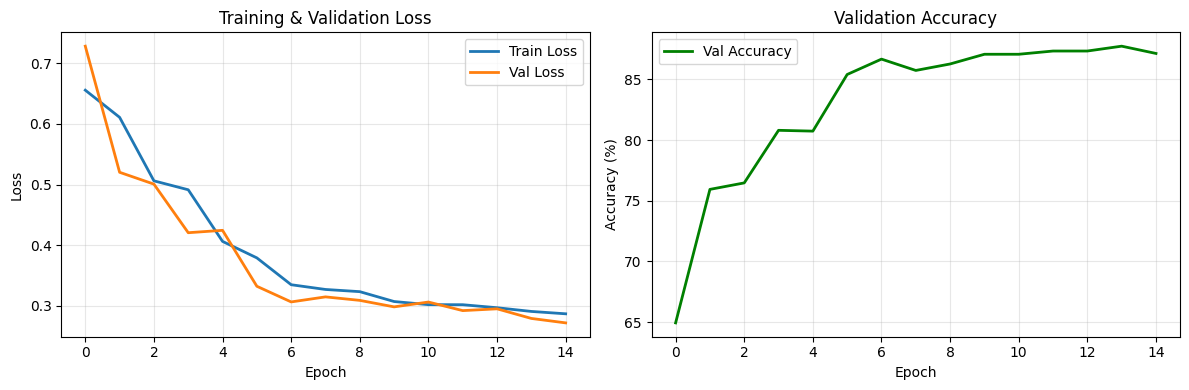

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy', linewidth=2, color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [76]:
import torch
import gc
torch.cuda.empty_cache()
gc.collect()

19157